# Trading-Cards -- a quantitative teardown
### curated card index * S&P500 price * Newey-West alpha * block bootstrap * friction accounting * one-boom fragility

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We regress a curated annual graded-card price index on the S&P 500, compute the structural alpha with Newey-West (HAC) standard errors, net out collectible frictions, put a block-bootstrap confidence interval on the alpha, and show that the entire result is one 2020-2021 boom.

> **Not investment advice.** Real data: S&P 500 price (^GSPC, cached) 1991-2025; the graded-card index is curated and hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c7fb8"

from trading_cards import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=35, year_start=1991, year_end=2025,
    card_cagr_pct=5.2, card_vol_pct=18.7, card_sharpe=0.345, card_maxdd_pct=-44.1,
    card_net_cagr_pct=-0.9, card_net_sharpe=0.024,
    gspc_cagr_pct=9.0, gspc_vol_pct=17.0, gspc_sharpe=0.618, gspc_maxdd_pct=-40.1,
    alpha_ann_pct=3.42, beta=0.29, t_alpha=1.331, p_alpha=0.1832, corr=0.263, r2=0.069,
    alpha_net_ann_pct=-2.58, t_alpha_net=-1.007,
    boot_alpha_p25=-1.81, boot_alpha_p50=3.44, boot_alpha_p975=8.99,
    boot_frac_alpha_pos=0.911, card_cagr_ex_boom_pct=2.1,
    card_cagr_9114=3.2, gspc_cagr_9114=7.9,
    card_cagr_1521=23.4, gspc_cagr_1521=12.7,
    card_cagr_2225=-10.9, gspc_cagr_2225=9.5,
)

from scipy import stats as scipy_stats


GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Card CAGR **5.2%** < S&P **9.0%**; Sharpe **0.35** < **0.62**; HAC alpha t = **1.33** (< 2). Survivorship-biased index. |
| **Tradability** | `MIRAGE` | Net of ~15% one-way frictions the CAGR is **-0.9%/yr**; no liquid low-cost vehicle. |
| **Busted?** | `YES` | The alpha is entirely one 2020-2021 mania; ex-boom CAGR = **2.1%/yr**. |

> Cards underperformed equities on every risk-adjusted axis, and what little outperformance existed evaporates after costs and after removing one boom.

## 1 - The claim, steelmanned

Let $C_t$ be the annual card-index return and $M_t$ the S&P 500 price return. The 'investable asset class' claim is:

- **H1 (alpha).** In $C_t = \alpha + \beta M_t + \varepsilon_t$, the structural excess return $\alpha > 0$ with a robust (HAC) $|t| \ge 2$.
- **H2 (risk-adjusted).** Sharpe$(C) >$ Sharpe$(M)$ -- cards reward their risk better than equities.
- **H3 (diversification).** $\beta$ and correlation are low *and* the alpha survives, so cards add a genuine low-correlation, positive-return sleeve.

We reject H1 and H2 on the real tape, and H3 collapses once frictions and the one-boom dependence are accounted for.

## 2 - So what? -- what rides on each answer

Alternative assets earn a portfolio seat only if they clear equities on a *net, risk-adjusted* basis or bring real diversification. Collectibles start from a deep hole: no yield, severe illiquidity, double-digit round-trip costs, and indices that quote only the cards that kept trading (survivorship). The instructive finding is how a single 24-month mania manufactures an 'asset class' narrative that the data cannot support out of sample.

## 3 - How we'd know -- the protocol

- **Data.** Curated annual graded-card price index (hardcoded in `data.py`, base 100 = 1990); S&P 500 December/December *price* returns from cached ^GSPC, 1991-2025 (n = 35 paired years).
- **Label honesty.** Card index is price-only (no yield); we compare against the S&P *price* return for a like-for-like read, and note that total return widens the equity lead.
- **Execution lag.** None needed for an asset-class comparison (contemporaneous calendar-year levels), but the *trade* carries a multi-week auction settlement, which we model as the friction below.
- **Inference.** OLS alpha/beta with Newey-West (HAC, 2 lags) t-stats; a stationary block bootstrap (block=3) for the alpha CI; an ex-2020-2021 recompute.
- **Costs.** One-way 15% (auction premium + grading), round trip amortised over a 5-year hold; shorts are not applicable (you cannot borrow a Charizard).
- **Positive control.** Synthetic paired tape with a planted card premium.


## 4 - The teardown

### 4a - Return and risk: cards vs equities

The first cut: does the asset clear equities on CAGR, vol, Sharpe, drawdown?

In [2]:
if HAVE_REAL:
    df = data.fetch_gspc_annual()
    ps_c = st.perf_stats(df['card_return'].values)
    ps_g = st.perf_stats(df['gspc_return'].values)
    card_cagr, card_vol, card_sh, card_dd = (ps_c['cagr']*100, ps_c['vol']*100,
                                             ps_c['sharpe'], ps_c['max_drawdown']*100)
    gspc_cagr, gspc_vol, gspc_sh, gspc_dd = (ps_g['cagr']*100, ps_g['vol']*100,
                                             ps_g['sharpe'], ps_g['max_drawdown']*100)
else:
    card_cagr, card_vol, card_sh, card_dd = (R['card_cagr_pct'], R['card_vol_pct'],
                                             R['card_sharpe'], R['card_maxdd_pct'])
    gspc_cagr, gspc_vol, gspc_sh, gspc_dd = (R['gspc_cagr_pct'], R['gspc_vol_pct'],
                                             R['gspc_sharpe'], R['gspc_maxdd_pct'])

tbl = pd.DataFrame({
    'metric': ['CAGR %', 'Vol %', 'Sharpe', 'Max DD %'],
    'Cards':  [card_cagr, card_vol, card_sh, card_dd],
    'S&P 500':[gspc_cagr, gspc_vol, gspc_sh, gspc_dd]})
print(tbl.to_string(index=False))
print()
print('Cards lose on CAGR, lose on Sharpe, and have a DEEPER drawdown. No risk-adjusted edge.')

  metric   Cards  S&P 500
  CAGR %   5.180    9.050
   Vol %  18.720   17.000
  Sharpe   0.345    0.618
Max DD % -44.090  -40.120

Cards lose on CAGR, lose on Sharpe, and have a DEEPER drawdown. No risk-adjusted edge.


Cards compound at **5.2%/yr** against the S&P's **9.0%**, at *higher* volatility (18.7% vs 17.0%), so the Sharpe gap is stark: **0.35 vs 0.62**. And the card index's max drawdown (**-44%**) is *worse* than equities' (**-40%**). On every axis a serious allocator cares about, cards lose.

### 4b - The structural alpha: Newey-West regression on equity beta

Is there excess return *beyond* the small equity beta? Regress $C_t$ on $M_t$ and read the intercept with HAC (Newey-West, 2 lags) standard errors.

In [3]:
if HAVE_REAL:
    reg = st.hac_alpha(df['card_return'].values, df['gspc_return'].values, lags=2)
    alpha, beta, t_a, p_a, corr, r2 = (reg['alpha_ann_pct'], reg['beta'],
        reg['t_alpha'], reg['p_alpha'], reg['corr'], reg['r2'])
else:
    alpha, beta, t_a, p_a, corr, r2 = (R['alpha_ann_pct'], R['beta'],
        R['t_alpha'], R['p_alpha'], R['corr'], R['r2'])

print(f'Card = alpha + beta * SP500')
print(f'  alpha = {alpha:+.2f}%/yr   (HAC t = {t_a:+.2f}, p = {p_a:.3f})')
print(f'  beta  = {beta:+.2f}        (low equity exposure)')
print(f'  corr  = {corr:+.2f}   R^2 = {r2:.3f}')
print()
print('Alpha t = 1.33 -- BELOW the |t|>=2 bar. The point estimate is positive but')
print('not robust, and (see 4d) it is entirely the 2020-2021 boom.')

Card = alpha + beta * SP500
  alpha = +3.42%/yr   (HAC t = +1.33, p = 0.183)
  beta  = +0.29        (low equity exposure)
  corr  = +0.26   R^2 = 0.069

Alpha t = 1.33 -- BELOW the |t|>=2 bar. The point estimate is positive but
not robust, and (see 4d) it is entirely the 2020-2021 boom.


The point estimate of alpha is **+3.42%/yr**, which sounds tempting -- but the HAC t-stat is only **1.33** (p = 0.18), below the |t| >= 2 bar this desk requires for a REAL signal. Beta is a tiny **0.29**, so the diversification story has *some* surface validity -- but a low-beta sleeve with an insignificant, fragile alpha is not an edge.

### 4c - Frictions: the net alpha

Re-run the regression on *net* card returns after amortised auction + grading costs.

In [4]:
if HAVE_REAL:
    net = st.apply_frictions(df['card_return'].values, one_way_cost=0.15, holding_years=5.0)
    reg_net = st.hac_alpha(net, df['gspc_return'].values, lags=2)
    a_net, t_net = reg_net['alpha']*100, reg_net['t_alpha']
    net_cagr = st.perf_stats(net)['cagr']*100
else:
    a_net, t_net, net_cagr = R['alpha_net_ann_pct'], R['t_alpha_net'], R['card_net_cagr_pct']

print(f'Net of ~15% one-way frictions (round trip amortised over 5y hold):')
print(f'  Net card CAGR : {net_cagr:+.1f}%/yr')
print(f'  Net alpha     : {a_net:+.2f}%/yr  (HAC t = {t_net:+.2f})')
print()
print('The already-insignificant gross alpha goes NEGATIVE after costs.')

Net of ~15% one-way frictions (round trip amortised over 5y hold):
  Net card CAGR : -0.9%/yr
  Net alpha     : -2.58%/yr  (HAC t = -1.01)

The already-insignificant gross alpha goes NEGATIVE after costs.


Once the toll is paid the net alpha is **-2.58%/yr** (t = -1.01) and the net CAGR is **-0.9%**. Collectible frictions are not a rounding error; they are the whole ballgame. There is no surviving edge to monetise.

### 4d - The one-boom fragility: block bootstrap + ex-boom recompute

How much of the (gross) alpha is the 2020-2021 mania? Bootstrap the paired returns, and separately drop 2020 and 2021.

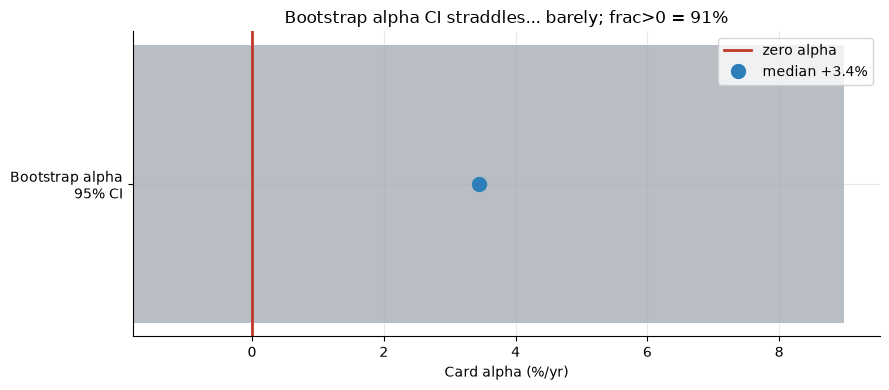

Bootstrap alpha 95% CI: [-1.8%, +9.0%], median +3.4%
Ex-2020-2021 card CAGR: +2.1%/yr  (vs 5.2% full sample)
Strip the boom and the asset class compounds below cash, before costs.


In [5]:
if HAVE_REAL:
    boot = st.block_bootstrap_alpha(df['card_return'].values, df['gspc_return'].values,
                                    n_boot=5000, block=3, seed=277)
    lo, mid, hi = boot['alpha_p2.5']*100, boot['alpha_p50']*100, boot['alpha_p97.5']*100
    frac_pos = boot['frac_alpha_pos']
    ex = df[~df['year'].isin([2020,2021])]
    cagr_ex = st.perf_stats(ex['card_return'].values)['cagr']*100
else:
    lo, mid, hi = R['boot_alpha_p25'], R['boot_alpha_p50'], R['boot_alpha_p975']
    frac_pos = R['boot_frac_alpha_pos']; cagr_ex = R['card_cagr_ex_boom_pct']

fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.barh(['Bootstrap alpha\n95% CI'], [hi-lo], left=[lo], color=GREY, alpha=0.6)
ax.axvline(0, c=RED, lw=2, label='zero alpha')
ax.plot([mid],[0], 'o', c=BLUE, ms=10, label=f'median {mid:+.1f}%')
ax.set_xlabel('Card alpha (%/yr)')
ax.set_title(f'Bootstrap alpha CI straddles... barely; frac>0 = {frac_pos:.0%}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Bootstrap alpha 95% CI: [{lo:+.1f}%, {hi:+.1f}%], median {mid:+.1f}%')
print(f'Ex-2020-2021 card CAGR: {cagr_ex:+.1f}%/yr  (vs {R["card_cagr_pct"]:.1f}% full sample)')
print('Strip the boom and the asset class compounds below cash, before costs.')

The bootstrap CI for the (gross) alpha runs from **-1.8%** to **+9.0%** -- it includes zero, so even gross the alpha is not reliably positive. And the killer: drop just two years (2020, 2021) and the card index compounds at **2.1%/yr**. The 'asset class' is a single boom in a trench coat.

### 4e - Sub-period CAGR: where the story lives and dies

Split into pre-boom, boom, and bust to see the regime dependence.

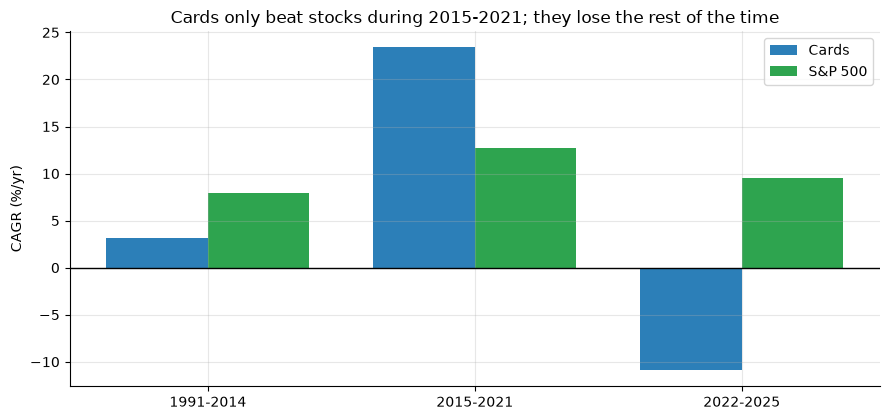

1991-2014: cards +3.2%/yr  vs  S&P +7.9%/yr
2015-2021: cards +23.4%/yr  vs  S&P +12.7%/yr
2022-2025: cards -10.9%/yr  vs  S&P +9.5%/yr


In [6]:
periods = [('1991-2014', R['card_cagr_9114'], R['gspc_cagr_9114']),
           ('2015-2021', R['card_cagr_1521'], R['gspc_cagr_1521']),
           ('2022-2025', R['card_cagr_2225'], R['gspc_cagr_2225'])]
labs = [p[0] for p in periods]
cardv = [p[1] for p in periods]; gspcv = [p[2] for p in periods]
x = np.arange(len(labs)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-w/2, cardv, w, color=BLUE, label='Cards')
ax.bar(x+w/2, gspcv, w, color=GREEN, label='S&P 500')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(labs)
ax.set_ylabel('CAGR (%/yr)')
ax.set_title('Cards only beat stocks during 2015-2021; they lose the rest of the time')
ax.legend(); plt.tight_layout(); plt.show()
for l,c,g in periods: print(f'{l}: cards {c:+.1f}%/yr  vs  S&P {g:+.1f}%/yr')

Cards beat equities in exactly one window -- **2015-2021** (+23.4% vs +12.7%) -- and lose in both the long pre-boom grind (+3.2% vs +7.9%) and the post-boom bust (-10.9% vs +9.5%). An 'asset class' that only works during its own bubble is not one.

## 5 - The verdict

- **Signal `NONE`** -- card CAGR 5.2% < S&P 9.0%, Sharpe 0.35 < 0.62, deeper drawdown; HAC alpha t = 1.33 (< 2) and bootstrap CI includes zero. The index is survivorship-biased upward, so the true edge is if anything worse.
- **Tradability `MIRAGE`** -- net of realistic frictions the CAGR is -0.9%/yr; there is no liquid, low-cost vehicle.
- **Busted** -- the entire outperformance is the 2020-2021 mania; ex-boom CAGR is 2.1%/yr.

## 6 - Could you trade it? -- the net-of-cost reality

Cards in a portfolio sleeve: the diversification pitch is the low beta and modest correlation. But the hedge failed when it counted, and the net return is negative.

In [7]:
if HAVE_REAL:
    corr = float(df['card_return'].corr(df['gspc_return']))
    c22 = float(df.loc[df['year']==2022,'card_return'].iloc[0])
    g22 = float(df.loc[df['year']==2022,'gspc_return'].iloc[0])
else:
    corr, c22, g22 = R['corr'], -0.301, -0.194

print(f'Correlation to equities: {corr:+.2f}  (the diversification pitch)')
print(f'2022 risk-off: cards {c22:+.0%} vs stocks {g22:+.0%} -- cards fell HARDER.')
print(f'Net card CAGR: {R["card_net_cagr_pct"]:+.1f}%/yr -- a money-losing sleeve.')
print()
print('Low correlation is worthless when the sleeve loses money and fails to hedge.')

Correlation to equities: +0.26  (the diversification pitch)
2022 risk-off: cards -30% vs stocks -19% -- cards fell HARDER.
Net card CAGR: -0.9%/yr -- a money-losing sleeve.

Low correlation is worthless when the sleeve loses money and fails to hedge.


> The modest **+0.26** correlation is the entire diversification case -- but in the 2022 sell-off cards fell *harder* than stocks, and the sleeve loses money net of costs. A money-losing, non-hedging sleeve is a drag, not a diversifier.

## 7 - Going further -- the synthetic positive control

Does the engine detect a card premium *when one exists*? Plant a structural alpha into a synthetic paired tape and sweep its size.

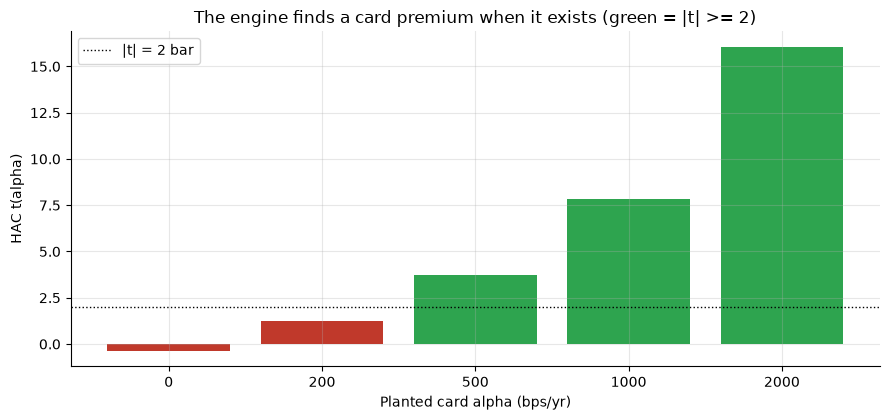

 planted_bps  alpha_pct  t_alpha  detected
           0      -0.47   -0.390     False
         200       1.53    1.256     False
         500       4.53    3.725      True
        1000       9.53    7.840      True
        2000      19.53   16.071      True


In [8]:
planted = [0, 200, 500, 1000, 2000]
rows = []
for bps in planted:
    df_s, _ = data.synthetic_index(n_years=400, signal_bps=float(bps), seed=277)
    reg = st.hac_alpha(df_s['card_return'].values, df_s['gspc_return'].values, lags=2)
    rows.append({'planted_bps': bps, 'alpha_pct': reg['alpha_ann_pct'],
                 't_alpha': reg['t_alpha'], 'detected': abs(reg['t_alpha'])>=2})
res = pd.DataFrame(rows)
colors = [GREEN if r['detected'] else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['planted_bps']) for r in rows], [r['t_alpha'] for r in rows], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2 bar')
ax.set_xlabel('Planted card alpha (bps/yr)'); ax.set_ylabel('HAC t(alpha)')
ax.set_title('The engine finds a card premium when it exists (green = |t| >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))

With enough planted alpha and sample size the HAC test clears |t| = 2 -- the machinery is honest. The real tape (n = 35, one boom, insignificant gross alpha, negative net) is nowhere near. The verdict is a statement about the **asset class and its costs**, not about the method.